In [ ]:
# Cell 1: Install required package
!pip install pvlib -q

In [ ]:
# Cell 2: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pvlib

In [ ]:
# Cell 3: Define location and time
# Pune, India
latitude = 18.5204
longitude = 73.8567
timezone = 'Asia/Kolkata'

times = pd.date_range(
    start='2026-04-15 09:00',
    end='2026-04-15 16:00',
    freq='5min',
    tz=timezone
)

location = pvlib.location.Location(
    latitude,
    longitude,
    tz=timezone,
    altitude=560,
    name='Pune'
)

solar_position = location.get_solarposition(times)

solar_position.head()

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time
2026-04-15 09:00:00+05:30,52.575069,52.595604,37.424931,37.404396,91.803062,-0.087633
2026-04-15 09:05:00+05:30,51.390823,51.410506,38.609177,38.589494,92.231280,-0.086795
2026-04-15 09:10:00+05:30,50.206880,50.225756,39.793120,39.774244,92.668176,-0.085958
2026-04-15 09:15:00+05:30,49.023323,49.041428,40.976677,40.958572,93.114579,-0.085120
2026-04-15 09:20:00+05:30,47.840235,47.857607,42.159765,42.142393,93.571392,-0.084283


In [ ]:
# Cell 4: Calculate clear-sky irradiance
clearsky = location.get_clearsky(times)

weather = pd.DataFrame(index=times)

weather['ghi'] = clearsky['ghi']
weather['dni'] = clearsky['dni']
weather['dhi'] = clearsky['dhi']

# Initial environmental assumptions
weather['temp_air'] = 35.0
weather['wind_speed'] = 1.5

weather.head()

,ghi,dni,dhi,temp_air,wind_speed
2026-04-15 09:00:00+05:30,560.152397,731.174240,115.802126,35.0,1.5
2026-04-15 09:05:00+05:30,579.321527,739.628623,117.789738,35.0,1.5
2026-04-15 09:10:00+05:30,598.201390,747.614152,119.715295,35.0,1.5
2026-04-15 09:15:00+05:30,616.779496,755.161498,121.581011,35.0,1.5
2026-04-15 09:20:00+05:30,635.043863,762.298655,123.388850,35.0,1.5


In [ ]:
# Cell 5: Conventional single-axis solar tracker

tracking = pvlib.tracking.singleaxis(
    apparent_zenith=solar_position['apparent_zenith'],
    solar_azimuth=solar_position['azimuth'],
    axis_tilt=0,
    axis_azimuth=180,
    max_angle=60,
    backtrack=True,
    gcr=0.35
)

tracking.head()

,tracker_theta,aoi,surface_azimuth,surface_tilt
2026-04-15 09:00:00+05:30,-52.561374,1.431815,90.0,52.561374
2026-04-15 09:05:00+05:30,-51.369630,1.743396,90.0,51.369630
2026-04-15 09:10:00+05:30,-50.176315,2.049817,90.0,50.176315
2026-04-15 09:15:00+05:30,-48.981388,2.350936,90.0,48.981388
2026-04-15 09:20:00+05:30,-47.784814,2.646614,90.0,47.784814


In [ ]:
# Cell 6: Define detacking angles

detack_angles = [0, 5, 10, 15, 20, 25, 30]

results = {}

In [ ]:
# Cell 7: Simulate detacking cases

# Example module parameters
area = 1.0                    # m²
eta_ref = 0.20                # 20% reference efficiency
temp_coeff = -0.004           # -0.4%/°C
T_ref = 25.0                  # reference temperature

for detack in detack_angles:

    surface_tilt = tracking['surface_tilt'].copy()
    surface_azimuth = tracking['surface_azimuth'].copy()

    # Simplified detacking:
    # move module tilt away from optimum tracking orientation
    adjusted_tilt = np.clip(surface_tilt + detack, 0, 90)

    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=adjusted_tilt,
        surface_azimuth=surface_azimuth,
        solar_zenith=solar_position['apparent_zenith'],
        solar_azimuth=solar_position['azimuth'],
        dni=weather['dni'],
        ghi=weather['ghi'],
        dhi=weather['dhi']
    )

    poa_global = poa['poa_global']

    # Faiman temperature model
    T_module = pvlib.temperature.faiman(
        poa_global=poa_global,
        temp_air=weather['temp_air'],
        wind_speed=weather['wind_speed']
    )

    # Temperature-corrected efficiency
    eta = eta_ref * (1 + temp_coeff * (T_module - T_ref))

    # Electrical power
    power = eta * poa_global * area

    results[detack] = pd.DataFrame({
        'POA': poa_global,
        'T_module': T_module,
        'Efficiency': eta,
        'Power': power
    })

In [ ]:
# Cell 7A — Geometrically consistent detacking

area = 1.0
eta_ref = 0.20
temp_coeff = -0.004
T_ref = 25.0

results = {}

base_theta = tracking['tracker_theta'].copy()

for detack in detack_angles:

    # Move tracker toward horizontal by 'detack' degrees.
    # This deliberately moves it away from sun-normal tracking.
    adjusted_theta = np.sign(base_theta) * np.maximum(
        np.abs(base_theta) - detack,
        0
    )

    # Convert tracker rotation to surface orientation
    surface = pvlib.tracking.calc_surface_orientation(
        tracker_theta=adjusted_theta,
        axis_tilt=0,
        axis_azimuth=180
    )

    adjusted_tilt = surface['surface_tilt']
    adjusted_azimuth = surface['surface_azimuth']

    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=adjusted_tilt,
        surface_azimuth=adjusted_azimuth,
        solar_zenith=solar_position['apparent_zenith'],
        solar_azimuth=solar_position['azimuth'],
        dni=weather['dni'],
        ghi=weather['ghi'],
        dhi=weather['dhi']
    )

    poa_global = poa['poa_global']

    T_module = pvlib.temperature.faiman(
        poa_global=poa_global,
        temp_air=weather['temp_air'],
        wind_speed=weather['wind_speed']
    )

    eta = eta_ref * (
        1 + temp_coeff * (T_module - T_ref)
    )

    power = eta * poa_global * area

    results[detack] = pd.DataFrame({
        'POA': poa_global,
        'T_module': T_module,
        'Efficiency': eta,
        'Power': power,
        'Tracker_angle': adjusted_theta,
        'Surface_tilt': adjusted_tilt,
        'Surface_azimuth': adjusted_azimuth
    })

In [ ]:
# Cell 8: Summary table

summary = []

for detack in detack_angles:

    df = results[detack]

    summary.append({
        'Detack_deg': detack,
        'Mean_POA_Wm2': df['POA'].mean(),
        'Max_Tmodule_C': df['T_module'].max(),
        'Mean_Tmodule_C': df['T_module'].mean(),
        'Mean_Power_W': df['Power'].mean(),
        'Daily_Energy_Wh': df['Power'].sum() * (5/60)
    })

summary_df = pd.DataFrame(summary)

baseline_energy = summary_df.loc[
    summary_df['Detack_deg'] == 0,
    'Daily_Energy_Wh'
].iloc[0]

summary_df['Energy_Change_%'] = (
    (summary_df['Daily_Energy_Wh'] - baseline_energy)
    / baseline_energy * 100
)

summary_df

,Detack_deg,Mean_POA_Wm2,Max_Tmodule_C,Mean_Tmodule_C,Mean_Power_W,Daily_Energy_Wh,Energy_Change_%
0,0,969.644523,63.745649,62.499845,164.794776,1167.296331,0.000000
1,5,965.716243,63.745616,62.388436,164.212463,1163.171610,-0.353357
2,10,956.997059,63.745616,62.141153,162.915795,1153.986880,-1.140195
3,15,944.737129,63.745616,61.793452,161.082168,1140.998693,-2.252867
4,20,930.194748,63.745616,61.381020,158.890200,1125.472252,-3.582987
5,25,914.613247,63.745616,60.939116,156.518703,1108.674146,-5.022048
6,30,899.197251,63.745616,60.501907,154.145300,1091.862544,-6.462265


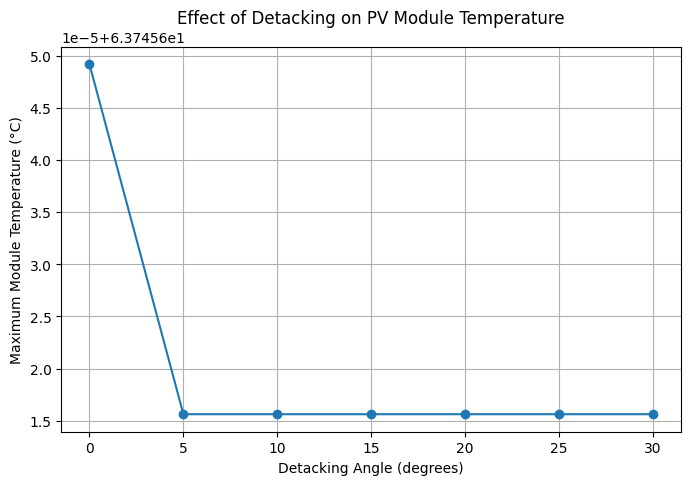

In [ ]:
# Cell 9: Plot detacking angle vs maximum module temperature

plt.figure(figsize=(8,5))
plt.plot(
    summary_df['Detack_deg'],
    summary_df['Max_Tmodule_C'],
    marker='o'
)

plt.xlabel('Detacking Angle (degrees)')
plt.ylabel('Maximum Module Temperature (°C)')
plt.title('Effect of Detacking on PV Module Temperature')
plt.grid(True)
plt.show()

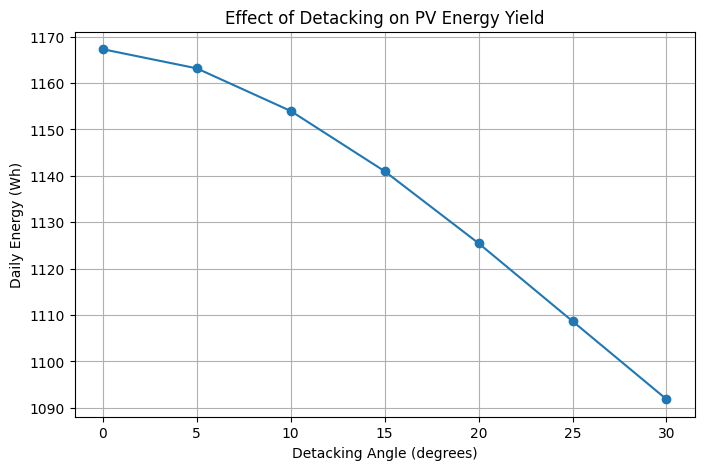

In [ ]:
# Cell 10: Plot detacking angle vs energy

plt.figure(figsize=(8,5))
plt.plot(
    summary_df['Detack_deg'],
    summary_df['Daily_Energy_Wh'],
    marker='o'
)

plt.xlabel('Detacking Angle (degrees)')
plt.ylabel('Daily Energy (Wh)')
plt.title('Effect of Detacking on PV Energy Yield')
plt.grid(True)
plt.show()

In [ ]:
# Cell 11: Temperature reduction vs energy penalty

baseline_temp = summary_df.loc[
    summary_df['Detack_deg'] == 0,
    'Max_Tmodule_C'
].iloc[0]

summary_df['Temp_Reduction_C'] = (
    baseline_temp - summary_df['Max_Tmodule_C']
)

summary_df['Energy_Penalty_%'] = (
    -summary_df['Energy_Change_%']
)

summary_df[
    [
        'Detack_deg',
        'Temp_Reduction_C',
        'Energy_Penalty_%'
    ]
]

,Detack_deg,Temp_Reduction_C,Energy_Penalty_%
0,0,0.000000,-0.000000
1,5,0.000034,0.353357
2,10,0.000034,1.140195
3,15,0.000034,2.252867
4,20,0.000034,3.582987
5,25,0.000034,5.022048
6,30,0.000034,6.462265


In [ ]:
# Cell 7B — True angular offset from conventional tracker position

detack_angles = [-30, -25, -20, -15, -10, -5,
                  0,
                  5, 10, 15, 20, 25, 30]

results = {}

area = 1.0
eta_ref = 0.20
temp_coeff = -0.004
T_ref = 25.0

base_theta = tracking['tracker_theta'].copy()

for detack in detack_angles:

    # Deliberately offset the tracker from its conventional position
    adjusted_theta = np.clip(
        base_theta + detack,
        -60,
        60
    )

    surface = pvlib.tracking.calc_surface_orientation(
        tracker_theta=adjusted_theta,
        axis_tilt=0,
        axis_azimuth=180
    )

    adjusted_tilt = surface['surface_tilt']
    adjusted_azimuth = surface['surface_azimuth']

    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=adjusted_tilt,
        surface_azimuth=adjusted_azimuth,
        solar_zenith=solar_position['apparent_zenith'],
        solar_azimuth=solar_position['azimuth'],
        dni=weather['dni'],
        ghi=weather['ghi'],
        dhi=weather['dhi']
    )

    poa_global = poa['poa_global']

    T_module = pvlib.temperature.faiman(
        poa_global=poa_global,
        temp_air=weather['temp_air'],
        wind_speed=weather['wind_speed']
    )

    eta = eta_ref * (
        1 + temp_coeff * (T_module - T_ref)
    )

    power = eta * poa_global * area

    results[detack] = pd.DataFrame({
        'POA': poa_global,
        'T_module': T_module,
        'Efficiency': eta,
        'Power': power,
        'Tracker_angle': adjusted_theta,
        'Surface_tilt': adjusted_tilt,
        'Surface_azimuth': adjusted_azimuth
    })

In [ ]:
# Cell 8B — Summary including high-temperature exposure

summary = []

dt_hours = 5 / 60

for detack in detack_angles:

    df = results[detack]

    summary.append({
        'Detack_deg': detack,

        'Mean_POA_Wm2':
            df['POA'].mean(),

        'Max_T_C':
            df['T_module'].max(),

        'Mean_T_C':
            df['T_module'].mean(),

        'Hours_above_60C':
            (df['T_module'] > 60).sum() * dt_hours,

        'Hours_above_62C':
            (df['T_module'] > 62).sum() * dt_hours,

        'Mean_Power_W':
            df['Power'].mean(),

        'Energy_Wh':
            df['Power'].sum() * dt_hours
    })

summary_df = pd.DataFrame(summary)

baseline = summary_df.loc[
    summary_df['Detack_deg'] == 0,
    'Energy_Wh'
].iloc[0]

summary_df['Energy_Loss_%'] = (
    (baseline - summary_df['Energy_Wh'])
    / baseline * 100
)

summary_df.round(3)

,Detack_deg,Mean_POA_Wm2,Max_T_C,Mean_T_C,Hours_above_60C,Hours_above_62C,Mean_Power_W,Energy_Wh,Energy_Loss_%
0,-30,876.399,60.710,59.855,4.500,0.000,150.816,1068.280,8.483
1,-25,902.216,61.623,60.588,5.500,0.000,154.729,1095.998,6.108
2,-20,924.857,62.380,61.230,6.000,2.500,158.132,1120.099,4.043
3,-15,943.605,62.974,61.761,6.250,3.833,160.930,1139.923,2.345
4,-10,957.763,63.401,62.163,6.500,4.583,163.034,1154.826,1.068
5,-5,966.656,63.659,62.415,6.583,4.833,164.353,1164.164,0.268
6,0,969.645,63.746,62.500,6.667,4.917,164.795,1167.296,0.000
7,5,966.618,63.660,62.414,6.583,4.917,164.347,1164.123,0.272
8,10,957.608,63.402,62.158,6.417,4.500,163.010,1154.658,1.083
9,15,943.130,62.974,61.748,6.167,3.917,160.857,1139.405,2.389


In [ ]:
!pip install pvlib -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pvlib

print("pvlib version:", pvlib.__version__)

pvlib version: 0.15.2


In [ ]:
# Re-import all libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pvlib

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
required_variables = [
    'times',
    'tracking',
    'results',
    'weather',
    'solar_position'
]

for var in required_variables:
    if var in globals():
        print(f"✓ {var} available")
    else:
        print(f"✗ {var} MISSING")

✓ times available
✓ tracking available
✓ results available
✓ weather available
✓ solar_position available


In [ ]:
# Cell 12 — Event-triggered minimum-detacking controller

T_limit = 62.0

candidate_angles = [
    0, -5, 5, -10, 10, -15, 15,
    -20, 20, -25, 25, -30, 30
]

controlled = pd.DataFrame(index=times)

chosen_angle = []
controlled_temp = []
controlled_power = []
controlled_poa = []

for t in times:

    # Normal tracking temperature
    T_normal = results[0].loc[t, 'T_module']

    # -------------------------------------------------
    # Normal operation: no thermal intervention needed
    # -------------------------------------------------
    if T_normal <= T_limit:

        angle = 0

        chosen_angle.append(angle)
        controlled_temp.append(
            results[0].loc[t, 'T_module']
        )
        controlled_power.append(
            results[0].loc[t, 'Power']
        )
        controlled_poa.append(
            results[0].loc[t, 'POA']
        )

        continue

    # -------------------------------------------------
    # Thermal intervention required
    # -------------------------------------------------

    feasible = []

    for angle in candidate_angles:

        T_candidate = results[angle].loc[t, 'T_module']
        P_candidate = results[angle].loc[t, 'Power']

        if T_candidate <= T_limit:

            feasible.append(
                (
                    abs(angle),
                    -P_candidate,
                    angle
                )
            )

    # -------------------------------------------------
    # Select smallest angular deviation
    # If tied, choose the higher-power direction
    # -------------------------------------------------

    if feasible:

        feasible.sort()

        angle = feasible[0][2]

    else:

        # If no candidate reaches target,
        # choose the coolest available state

        angle = min(
            candidate_angles,
            key=lambda a:
            results[a].loc[t, 'T_module']
        )

    chosen_angle.append(angle)

    controlled_temp.append(
        results[angle].loc[t, 'T_module']
    )

    controlled_power.append(
        results[angle].loc[t, 'Power']
    )

    controlled_poa.append(
        results[angle].loc[t, 'POA']
    )


controlled['Detack_deg'] = chosen_angle
controlled['T_module'] = controlled_temp
controlled['Power'] = controlled_power
controlled['POA'] = controlled_poa

In [ ]:
# Cell 13 — Compare conventional vs event-triggered tracking

dt_hours = 5 / 60

baseline_energy = (
    results[0]['Power'].sum() * dt_hours
)

controlled_energy = (
    controlled['Power'].sum() * dt_hours
)

energy_loss_pct = (
    (baseline_energy - controlled_energy)
    / baseline_energy * 100
)

baseline_above_62 = (
    (results[0]['T_module'] > 62).sum()
    * dt_hours
)

controlled_above_62 = (
    (controlled['T_module'] > 62).sum()
    * dt_hours
)

baseline_above_60 = (
    (results[0]['T_module'] > 60).sum()
    * dt_hours
)

controlled_above_60 = (
    (controlled['T_module'] > 60).sum()
    * dt_hours
)

comparison = pd.DataFrame({
    'Metric': [
        'Energy (Wh)',
        'Energy loss (%)',
        'Maximum temperature (°C)',
        'Hours > 60°C',
        'Hours > 62°C'
    ],

    'Conventional Tracking': [
        baseline_energy,
        0,
        results[0]['T_module'].max(),
        baseline_above_60,
        baseline_above_62
    ],

    'Event-Triggered Tracking': [
        controlled_energy,
        energy_loss_pct,
        controlled['T_module'].max(),
        controlled_above_60,
        controlled_above_62
    ]
})

comparison.round(3)

,Metric,Conventional Tracking,Event-Triggered Tracking
0,Energy (Wh),1167.296,1129.586
1,Energy loss (%),0.000,3.231
2,Maximum temperature (°C),63.746,61.999
3,Hours > 60°C,6.667,6.667
4,Hours > 62°C,4.917,0.000


In [ ]:
# Cell 14 — How often each detacking angle was used

angle_usage = (
    controlled['Detack_deg']
    .value_counts()
    .sort_index()
)

angle_usage

,count
Detack_deg,
-25,12
-20,10
-15,5
-10,2
-5,1
0,26
10,3
15,4
20,9


In [ ]:
# Notebook 2 - Cell 1
# Parameters for transient PV thermal model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optical / electrical parameters
tau_alpha = 0.86       # effective transmittance-absorptance
eta_ref = 0.20         # reference electrical efficiency
beta_T = -0.004        # efficiency temperature coefficient, per °C
T_ref = 25.0           # °C

# Areal thermal capacitance, J/(m² K)
C_A = 5507.0

# Faiman-type heat-loss coefficients
U0 = 25.0              # W/(m² K)
U1 = 6.84              # W/(m² K)/(m/s)

print("Transient thermal parameters loaded.")

Transient thermal parameters loaded.


In [ ]:
# Notebook 2 - Cell 2

def pv_efficiency(T_module):
    """
    Temperature-dependent PV efficiency.
    T_module in °C
    """
    return eta_ref * (1 + beta_T * (T_module - T_ref))

In [ ]:
# Notebook 2 - Cell 3

def transient_temperature_step(
    T_prev,
    poa,
    temp_air,
    wind_speed,
    dt_seconds
):
    """
    One-step lumped transient PV thermal model.
    """

    eta = pv_efficiency(T_prev)

    # Heat absorbed from solar radiation
    q_abs = tau_alpha * poa

    # Electrical energy removed
    q_elec = eta * poa

    # Combined heat loss
    U = U0 + U1 * wind_speed
    q_loss = U * (T_prev - temp_air)

    # Energy balance
    dTdt = (
        q_abs
        - q_elec
        - q_loss
    ) / C_A

    T_new = T_prev + dTdt * dt_seconds

    return T_new

In [ ]:
# Notebook 2 - Cell 4
# Transient simulation for conventional tracking

dt_seconds = 5 * 60

T_transient = []

# Start module at ambient temperature
T_current = weather['temp_air'].iloc[0]

for t in times:

    poa = results[0].loc[t, 'POA']
    Ta = weather.loc[t, 'temp_air']
    wind = weather.loc[t, 'wind_speed']

    T_current = transient_temperature_step(
        T_prev=T_current,
        poa=poa,
        temp_air=Ta,
        wind_speed=wind,
        dt_seconds=dt_seconds
    )

    T_transient.append(T_current)

transient_df = pd.DataFrame(
    index=times,
    data={'T_transient': T_transient}
)

transient_df.head()

,T_transient
2026-04-15 09:00:00+05:30,65.986105
2026-04-15 09:05:00+05:30,39.005270
2026-04-15 09:10:00+05:30,63.204030
2026-04-15 09:15:00+05:30,42.198226
2026-04-15 09:20:00+05:30,61.062857


In [ ]:
# Notebook 2 - Cell 5
# Add steady-state Faiman temperature for comparison

transient_df['T_faiman'] = results[0]['T_module']

transient_df['Difference_C'] = (
    transient_df['T_transient']
    - transient_df['T_faiman']
)

transient_df.head()

,T_transient,T_faiman,Difference_C
2026-04-15 09:00:00+05:30,65.986105,59.149160,6.836944
2026-04-15 09:05:00+05:30,39.005270,59.451380,-20.446110
2026-04-15 09:10:00+05:30,63.204030,59.736670,3.467359
2026-04-15 09:15:00+05:30,42.198226,60.005999,-17.807773
2026-04-15 09:20:00+05:30,61.062857,60.260263,0.802593


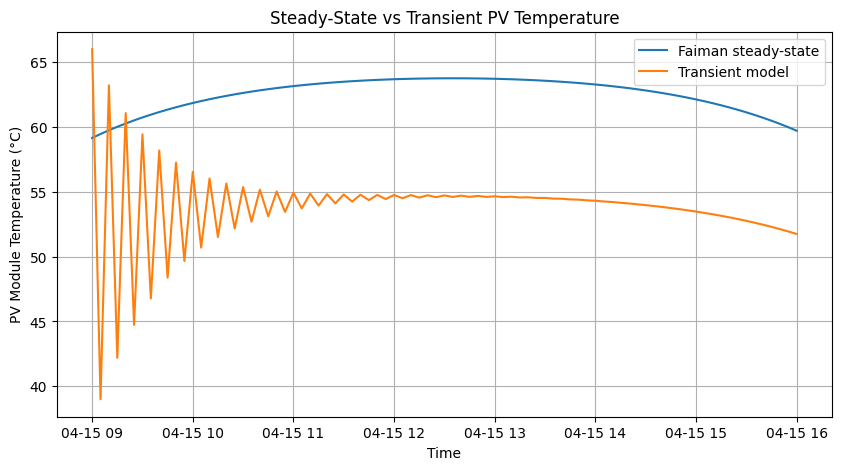

In [ ]:
# Notebook 2 - Cell 6

plt.figure(figsize=(10,5))

plt.plot(
    transient_df.index,
    transient_df['T_faiman'],
    label='Faiman steady-state'
)

plt.plot(
    transient_df.index,
    transient_df['T_transient'],
    label='Transient model'
)

plt.xlabel('Time')
plt.ylabel('PV Module Temperature (°C)')
plt.title('Steady-State vs Transient PV Temperature')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Notebook 2 - Cell 7

comparison_thermal = pd.DataFrame({
    'Metric': [
        'Maximum temperature (°C)',
        'Mean temperature (°C)',
        'Time of maximum temperature'
    ],
    'Faiman': [
        transient_df['T_faiman'].max(),
        transient_df['T_faiman'].mean(),
        transient_df['T_faiman'].idxmax()
    ],
    'Transient': [
        transient_df['T_transient'].max(),
        transient_df['T_transient'].mean(),
        transient_df['T_transient'].idxmax()
    ]
})

comparison_thermal

,Metric,Faiman,Transient
0,Maximum temperature (°C),63.745649,65.986105
1,Mean temperature (°C),62.499845,53.876457
2,Time of maximum temperature,2026-04-15 12:35:00+05:30,2026-04-15 09:00:00+05:30


In [ ]:
# Notebook 2 - Corrected Cell 3
# Transient extension consistent with Faiman steady state

def transient_temperature_step(
    T_prev,
    poa,
    temp_air,
    wind_speed,
    dt_seconds
):
    """
    Transient PV temperature model consistent with
    the Faiman steady-state temperature equation.
    """

    U = U0 + U1 * wind_speed

    dTdt = (
        poa
        - U * (T_prev - temp_air)
    ) / C_A

    T_new = T_prev + dTdt * dt_seconds

    return T_new

In [ ]:
# Notebook 2 - Corrected Cell 4
# 10-second internal thermal integration
# while environmental inputs remain at 5-minute resolution

data_interval_seconds = 5 * 60
internal_dt = 10

n_substeps = int(data_interval_seconds / internal_dt)

T_transient = []

# Start at the Faiman equilibrium corresponding
# to the first available weather point.
first_t = times[0]

first_poa = results[0].loc[first_t, 'POA']
first_Ta = weather.loc[first_t, 'temp_air']
first_wind = weather.loc[first_t, 'wind_speed']

first_U = U0 + U1 * first_wind

T_current = first_Ta + first_poa / first_U

for t in times:

    poa = results[0].loc[t, 'POA']
    Ta = weather.loc[t, 'temp_air']
    wind = weather.loc[t, 'wind_speed']

    # Integrate internally using small time steps
    for _ in range(n_substeps):

        T_current = transient_temperature_step(
            T_prev=T_current,
            poa=poa,
            temp_air=Ta,
            wind_speed=wind,
            dt_seconds=internal_dt
        )

    T_transient.append(T_current)


transient_df = pd.DataFrame(
    index=times,
    data={'T_transient': T_transient}
)

print(transient_df.head())

                           T_transient
2026-04-15 09:00:00+05:30    59.149160
2026-04-15 09:05:00+05:30    59.409864
2026-04-15 09:10:00+05:30    59.691777
2026-04-15 09:15:00+05:30    59.962835
2026-04-15 09:20:00+05:30    60.219406


In [ ]:
# Corrected Cell 5

transient_df['T_faiman'] = results[0]['T_module']

transient_df['Difference_C'] = (
    transient_df['T_transient']
    - transient_df['T_faiman']
)

transient_df.head()

,T_transient,T_faiman,Difference_C
2026-04-15 09:00:00+05:30,59.149160,59.149160,0.000000
2026-04-15 09:05:00+05:30,59.409864,59.451380,-0.041516
2026-04-15 09:10:00+05:30,59.691777,59.736670,-0.044893
2026-04-15 09:15:00+05:30,59.962835,60.005999,-0.043165
2026-04-15 09:20:00+05:30,60.219406,60.260263,-0.040858


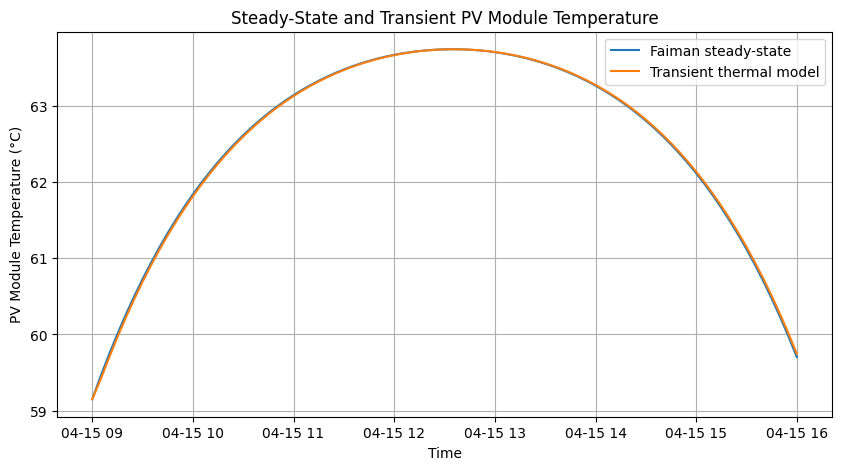

In [ ]:
# Corrected Cell 6

plt.figure(figsize=(10,5))

plt.plot(
    transient_df.index,
    transient_df['T_faiman'],
    label='Faiman steady-state'
)

plt.plot(
    transient_df.index,
    transient_df['T_transient'],
    label='Transient thermal model'
)

plt.xlabel('Time')
plt.ylabel('PV Module Temperature (°C)')
plt.title('Steady-State and Transient PV Module Temperature')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Corrected Cell 7

mae = np.mean(
    np.abs(
        transient_df['T_transient']
        - transient_df['T_faiman']
    )
)

rmse = np.sqrt(
    np.mean(
        (
            transient_df['T_transient']
            - transient_df['T_faiman']
        )**2
    )
)

comparison_thermal = pd.DataFrame({
    'Metric': [
        'Maximum temperature (°C)',
        'Mean temperature (°C)',
        'Time of maximum temperature',
        'MAE vs Faiman (°C)',
        'RMSE vs Faiman (°C)'
    ],

    'Faiman': [
        transient_df['T_faiman'].max(),
        transient_df['T_faiman'].mean(),
        transient_df['T_faiman'].idxmax(),
        0,
        0
    ],

    'Transient': [
        transient_df['T_transient'].max(),
        transient_df['T_transient'].mean(),
        transient_df['T_transient'].idxmax(),
        mae,
        rmse
    ]
})

comparison_thermal

,Metric,Faiman,Transient
0,Maximum temperature (°C),63.745649,63.745352
1,Mean temperature (°C),62.499845,62.498726
2,Time of maximum temperature,2026-04-15 12:35:00+05:30,2026-04-15 12:35:00+05:30
3,MAE vs Faiman (°C),0,0.016103
4,RMSE vs Faiman (°C),0,0.020565


In [ ]:
# Notebook 3 - Cell 1
# Arrhenius thermal stress model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

k_B = 8.617333262e-5   # eV/K

Ea_nominal = 0.43      # eV
Tref_C = 25.0
Tref_K = Tref_C + 273.15

def arrhenius_acceleration(T_C, Ea=Ea_nominal):
    """
    Relative thermal acceleration factor
    referenced to 25 °C.
    """
    T_K = np.asarray(T_C) + 273.15

    AF = np.exp(
        (Ea / k_B) *
        (1.0 / Tref_K - 1.0 / T_K)
    )

    return AF

In [ ]:
# Notebook 3 - Cell 2
# Visualize thermal acceleration factor

temperatures = np.arange(25, 81, 1)

AF_values = arrhenius_acceleration(
    temperatures,
    Ea=Ea_nominal
)

thermal_curve = pd.DataFrame({
    'Temperature_C': temperatures,
    'Acceleration_Factor': AF_values
})

thermal_curve.head()

,Temperature_C,Acceleration_Factor
0,25,1.000000
1,26,1.057541
2,27,1.117976
3,28,1.181429
4,29,1.248026


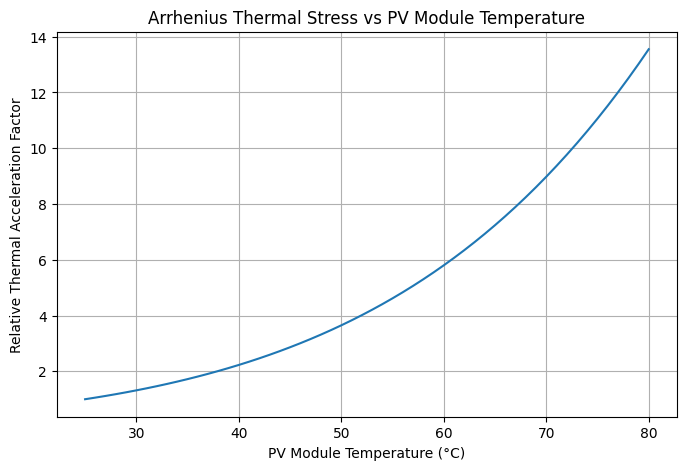

In [ ]:
# Notebook 3 - Cell 3

plt.figure(figsize=(8,5))

plt.plot(
    thermal_curve['Temperature_C'],
    thermal_curve['Acceleration_Factor']
)

plt.xlabel('PV Module Temperature (°C)')
plt.ylabel('Relative Thermal Acceleration Factor')
plt.title('Arrhenius Thermal Stress vs PV Module Temperature')
plt.grid(True)

plt.show()

In [ ]:
# Notebook 3 - Cell 4
# Accumulated thermal dose

dt_hours = 5 / 60

def thermal_dose(T_series, Ea=Ea_nominal):
    AF = arrhenius_acceleration(
        T_series,
        Ea=Ea
    )

    dose = np.sum(AF * dt_hours)

    return dose

In [ ]:
# Notebook 3 - Cell 5
# Thermal dose comparison

dose_conventional = thermal_dose(
    results[0]['T_module'],
    Ea=Ea_nominal
)

dose_event = thermal_dose(
    controlled['T_module'],
    Ea=Ea_nominal
)

dose_reduction_pct = (
    (dose_conventional - dose_event)
    / dose_conventional * 100
)

thermal_dose_comparison = pd.DataFrame({
    'Strategy': [
        'Conventional Tracking',
        'Event-Triggered Tracking'
    ],

    'Thermal_Dose': [
        dose_conventional,
        dose_event
    ]
})

thermal_dose_comparison['Dose_Reduction_%'] = [
    0,
    dose_reduction_pct
]

thermal_dose_comparison.round(3)

,Strategy,Thermal_Dose,Dose_Reduction_%
0,Conventional Tracking,46.013,0.000
1,Event-Triggered Tracking,43.929,4.529


In [ ]:
# Notebook 3 - Cell 6
# Thermal stress reduction per energy penalty

energy_penalty = energy_loss_pct

TSER = dose_reduction_pct / energy_penalty

print(
    f"Thermal dose reduction = "
    f"{dose_reduction_pct:.2f}%"
)

print(
    f"Energy penalty = "
    f"{energy_penalty:.2f}%"
)

print(
    f"Thermal-stress reduction per "
    f"1% energy sacrificed = {TSER:.2f}"
)

Thermal dose reduction = 4.53%
Energy penalty = 3.23%
Thermal-stress reduction per 1% energy sacrificed = 1.40


In [ ]:
# Notebook 3 - Cell 7
# Sensitivity to activation energy

Ea_values = [
    0.30,
    0.43,
    0.50,
    0.70,
    0.90
]

sensitivity = []

for Ea in Ea_values:

    D0 = thermal_dose(
        results[0]['T_module'],
        Ea=Ea
    )

    De = thermal_dose(
        controlled['T_module'],
        Ea=Ea
    )

    reduction = (
        (D0 - De) / D0 * 100
    )

    sensitivity.append({
        'Ea_eV': Ea,
        'Dose_Conventional': D0,
        'Dose_EventTriggered': De,
        'Dose_Reduction_%': reduction
    })

sensitivity_df = pd.DataFrame(sensitivity)

sensitivity_df.round(3)

,Ea_eV,Dose_Conventional,Dose_EventTriggered,Dose_Reduction_%
0,0.30,26.125,25.300,3.159
1,0.43,46.013,43.929,4.529
2,0.50,62.415,59.128,5.267
3,0.70,149.212,138.210,7.373
4,0.90,356.933,323.116,9.474


In [ ]:
# Notebook 4 - Cell 1
# Candidate detacking angles

candidate_angles = [
    -30, -25, -20, -15, -10, -5,
     0,
     5, 10, 15, 20, 25, 30
]

dt_hours = 5 / 60

In [ ]:
# Notebook 4 - Cell 2

def instantaneous_thermal_cost(T_C, Ea=0.43):

    AF = arrhenius_acceleration(
        T_C,
        Ea=Ea
    )

    return AF * dt_hours

In [ ]:
# Notebook 4 - Cell 3

records = []

for t in times:

    for angle in candidate_angles:

        records.append({

            'time': t,

            'angle': angle,

            'temperature':
                results[angle].loc[t, 'T_module'],

            'power':
                results[angle].loc[t, 'Power'],

            'thermal_cost':
                instantaneous_thermal_cost(
                    results[angle].loc[t, 'T_module'],
                    Ea=0.43
                )
        })

action_table = pd.DataFrame(records)

action_table.head()

,time,angle,temperature,power,thermal_cost
0,2026-04-15 09:00:00+05:30,-30,59.011784,146.294089,0.462465
1,2026-04-15 09:00:00+05:30,-25,59.011784,146.294089,0.462465
2,2026-04-15 09:00:00+05:30,-20,59.011784,146.294089,0.462465
3,2026-04-15 09:00:00+05:30,-15,59.011784,146.294089,0.462465
4,2026-04-15 09:00:00+05:30,-10,59.011784,146.294089,0.462465


In [ ]:
# Notebook 4 - Cell 4

baseline_power = results[0]['Power']

action_table['baseline_power'] = (
    action_table['time']
    .map(baseline_power)
)

action_table['energy_loss_Wh'] = (
    (
        action_table['baseline_power']
        - action_table['power']
    )
    * dt_hours
)

action_table.head()

,time,angle,temperature,power,thermal_cost,baseline_power,energy_loss_Wh
0,2026-04-15 09:00:00+05:30,-30,59.011784,146.294089,0.462465,147.037488,0.06195
1,2026-04-15 09:00:00+05:30,-25,59.011784,146.294089,0.462465,147.037488,0.06195
2,2026-04-15 09:00:00+05:30,-20,59.011784,146.294089,0.462465,147.037488,0.06195
3,2026-04-15 09:00:00+05:30,-15,59.011784,146.294089,0.462465,147.037488,0.06195
4,2026-04-15 09:00:00+05:30,-10,59.011784,146.294089,0.462465,147.037488,0.06195


In [ ]:
# Notebook 4 - Cell 5
# Baseline quantities

baseline_energy = (
    results[0]['Power'].sum()
    * dt_hours
)

baseline_dose = thermal_dose(
    results[0]['T_module'],
    Ea=0.43
)

print("Baseline energy:", baseline_energy)
print("Baseline thermal dose:", baseline_dose)

Baseline energy: 1167.2963306790366
Baseline thermal dose: 46.0126155740834


In [ ]:
# Corrected Notebook 4 - Cell 6

candidate_angles = [
    -30, -25, -20, -15, -10, -5,
     0,
     5, 10, 15, 20, 25, 30
]

dt_hours = 5 / 60

candidate_data = {}

for t in times:

    actions = []

    base_power = results[0].loc[t, 'Power']
    base_energy = base_power * dt_hours

    base_temp = results[0].loc[t, 'T_module']

    base_dose = (
        arrhenius_acceleration(
            base_temp,
            Ea=0.43
        ) * dt_hours
    )

    for angle in candidate_angles:

        temp = results[angle].loc[t, 'T_module']
        power = results[angle].loc[t, 'Power']

        energy = power * dt_hours

        dose = (
            arrhenius_acceleration(
                temp,
                Ea=0.43
            ) * dt_hours
        )

        actions.append({
            'angle': angle,
            'energy_Wh': energy,
            'dose': dose,
            'energy_loss_Wh':
                base_energy - energy,
            'dose_saved':
                base_dose - dose
        })

    candidate_data[t] = actions

print(
    "Timesteps:", len(candidate_data),
    "Actions per timestep:",
    len(candidate_angles)
)

Timesteps: 85 Actions per timestep: 13


In [ ]:
# Corrected Notebook 4 - Cell 7

import scipy
from scipy.optimize import milp, LinearConstraint, Bounds

print("SciPy version:", scipy.__version__)

SciPy version: 1.16.3


In [ ]:
# Corrected Notebook 4 - Cell 8

all_records = []

for ti, t in enumerate(times):

    for ai, action in enumerate(candidate_data[t]):

        all_records.append({
            'time_index': ti,
            'time': t,
            'angle_index': ai,
            'angle': action['angle'],
            'energy_Wh': action['energy_Wh'],
            'dose': action['dose']
        })

opt_df = pd.DataFrame(all_records)

n_vars = len(opt_df)

print("Optimization variables:", n_vars)

Optimization variables: 1105


In [ ]:
# Corrected Notebook 4 - Cell 9

def optimize_for_energy_budget(
    allowed_loss_pct
):

    # Objective:
    # minimize total thermal dose
    c = opt_df['dose'].values

    # All variables binary
    integrality = np.ones(n_vars)

    bounds = Bounds(
        lb=np.zeros(n_vars),
        ub=np.ones(n_vars)
    )

    constraints = []

    # -----------------------------------
    # Constraint 1:
    # exactly one action per timestep
    # -----------------------------------

    A_time = np.zeros(
        (len(times), n_vars)
    )

    for j, row in opt_df.iterrows():
        A_time[
            int(row['time_index']),
            j
        ] = 1

    constraints.append(
        LinearConstraint(
            A_time,
            lb=np.ones(len(times)),
            ub=np.ones(len(times))
        )
    )

    # -----------------------------------
    # Constraint 2:
    # minimum required energy
    # -----------------------------------

    minimum_energy = (
        baseline_energy
        * (1 - allowed_loss_pct / 100)
    )

    energy_vector = (
        opt_df['energy_Wh'].values
    )

    constraints.append(
        LinearConstraint(
            energy_vector.reshape(1, -1),
            lb=[minimum_energy],
            ub=[np.inf]
        )
    )

    result = milp(
        c=c,
        integrality=integrality,
        bounds=bounds,
        constraints=constraints,
        options={'time_limit': 60}
    )

    return result

In [ ]:
# Corrected Notebook 4 - Cell 10

energy_budgets_pct = [
    0.0,
    0.25,
    0.5,
    0.75,
    1.0,
    1.5,
    2.0,
    2.5,
    3.0,
    4.0,
    5.0
]

pareto_results = []
solutions = {}

for budget in energy_budgets_pct:

    result = optimize_for_energy_budget(
        budget
    )

    if not result.success:
        print(
            f"Optimization failed "
            f"for {budget}%"
        )
        continue

    selected = opt_df[
        result.x > 0.5
    ].copy()

    total_energy = (
        selected['energy_Wh'].sum()
    )

    total_dose = (
        selected['dose'].sum()
    )

    actual_loss_pct = (
        (baseline_energy - total_energy)
        / baseline_energy
        * 100
    )

    dose_reduction_pct = (
        (baseline_dose - total_dose)
        / baseline_dose
        * 100
    )

    interventions = (
        selected['angle'] != 0
    ).sum()

    pareto_results.append({
        'Allowed_Energy_Loss_%':
            budget,

        'Actual_Energy_Loss_%':
            actual_loss_pct,

        'Thermal_Dose_Reduction_%':
            dose_reduction_pct,

        'Interventions':
            interventions
    })

    solutions[budget] = selected


pareto_df = pd.DataFrame(
    pareto_results
)

pareto_df.round(3)

,Allowed_Energy_Loss_%,Actual_Energy_Loss_%,Thermal_Dose_Reduction_%,Interventions
0,0.00,-0.000,0.000,0
1,0.25,0.249,0.366,27
2,0.50,0.500,0.729,37
3,0.75,0.749,1.089,39
4,1.00,0.996,1.442,45
5,1.50,1.499,2.151,50
6,2.00,1.999,2.849,55
7,2.50,2.498,3.534,59
8,3.00,2.999,4.216,61
9,4.00,4.000,5.558,68


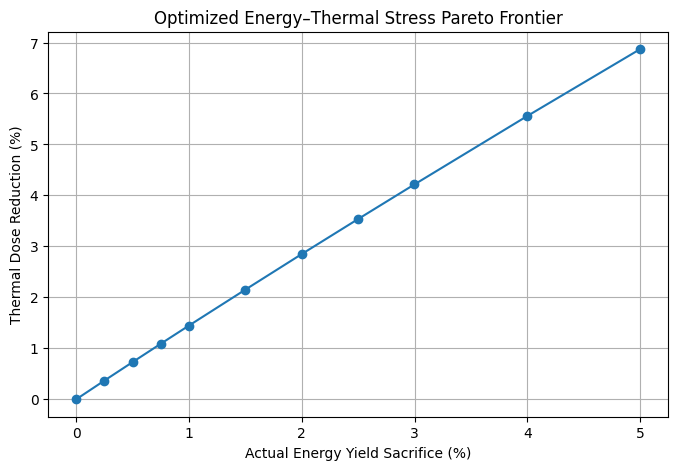

In [ ]:
# Corrected Notebook 4 - Cell 11

plt.figure(figsize=(8,5))

plt.plot(
    pareto_df['Actual_Energy_Loss_%'],
    pareto_df['Thermal_Dose_Reduction_%'],
    marker='o'
)

plt.xlabel(
    'Actual Energy Yield Sacrifice (%)'
)

plt.ylabel(
    'Thermal Dose Reduction (%)'
)

plt.title(
    'Optimized Energy–Thermal Stress Pareto Frontier'
)

plt.grid(True)

plt.show()

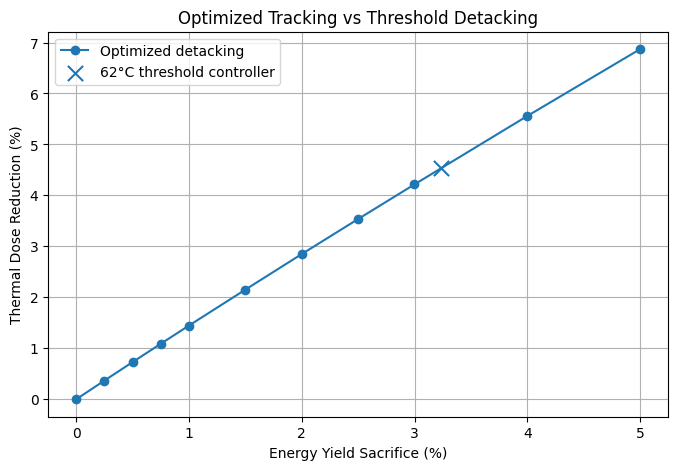

In [ ]:
# Cell 12 - Compare threshold controller

plt.figure(figsize=(8,5))

plt.plot(
    pareto_df['Actual_Energy_Loss_%'],
    pareto_df['Thermal_Dose_Reduction_%'],
    marker='o',
    label='Optimized detacking'
)

plt.scatter(
    [3.231],
    [4.529],
    marker='x',
    s=120,
    label='62°C threshold controller'
)

plt.xlabel(
    'Energy Yield Sacrifice (%)'
)

plt.ylabel(
    'Thermal Dose Reduction (%)'
)

plt.title(
    'Optimized Tracking vs Threshold Detacking'
)

plt.legend()
plt.grid(True)

plt.show()